# [Demo] Injetando Configs e Runtime Context

O agente da Clínica Alura hoje trata toda conversa do mesmo jeito: mesmo modelo, mesmo prompt, não importa
quem está do outro lado nem em qual unidade. Aqui ele passa a saber das duas coisas, cada uma do seu jeito.

O que vamos ver:
- `config["configurable"]`, pra configuração de execução que a aplicação decide, como qual modelo usar;
- `@dataclass` + `context_schema` + `Runtime`, pra dado de domínio tipado, como paciente e unidade;
- os dois parâmetros coexistindo na mesma função de nó;
- prompt de sistema mudando por paciente, sem middleware;
- o mesmo `context_schema` funcionando também num `create_agent`.

## Setup

Carregamos as libs, as variáveis de ambiente (a chave `OPENAI_API_KEY` vem do `.env`) e inicializamos o modelo uma vez.

In [1]:
from dataclasses import dataclass
from IPython.display import Image, display
from langchain.agents import create_agent
from langchain.messages import HumanMessage, SystemMessage
from langchain_core.runnables import RunnableConfig
from langchain_openai import ChatOpenAI
from langgraph.graph import END, START, MessagesState, StateGraph
from langgraph.runtime import Runtime
from dotenv import load_dotenv

In [2]:
load_dotenv()

True

In [3]:
model = ChatOpenAI(model="gpt-4o-mini", temperature=0)

## config["configurable"]: configuração de execução

`config` é o segundo parâmetro que o LangGraph já passa pra toda função de nó, com `"configurable"`
reservado pra isso. É o lugar certo pra configuração que a aplicação decide sobre a execução, não sobre o
domínio do negócio: qual modelo rodar, qual temperatura usar.

In [4]:
def choose_model_and_answer(state: MessagesState, config: RunnableConfig) -> dict:
    model = ChatOpenAI(
        model=config["configurable"]["model_name"],
        temperature=config["configurable"]["temperature"],
    )
    response = model.invoke(state["messages"])
    return {"messages": [response]}

In [5]:
builder_config = StateGraph(MessagesState)
builder_config.add_node("choose_model_and_answer", choose_model_and_answer)
builder_config.add_edge(START, "choose_model_and_answer")
builder_config.add_edge("choose_model_and_answer", END)
graph_config = builder_config.compile()

In [11]:
response_temp_0 = graph_config.invoke(
    {"messages": [HumanMessage("Sugira um nome curto para uma clínica de bairro.")]},
    config={"configurable": {"model_name": "gpt-4o-mini", "temperature": 0}},
)
print(response_temp_0["messages"][-1].content)

"Clínica Vida"


In [13]:
response_temp_1 = graph_config.invoke(
    {"messages": [HumanMessage("Sugira um nome curto para uma clínica de bairro.")]},
    config={"configurable": {"model_name": "gpt-4o-mini", "temperature": 1}},
)
print(response_temp_1["messages"][-1].content)

Claro! Que tal "Clínica Bem Viver"? É um nome curto e transmite a ideia de bem-estar.


O mesmo grafo compilado respondeu diferente sem recompilar nada: só o `config` mudou entre uma chamada e
outra. `model_name` e `temperature` vieram de quem chamou o grafo, não do código do nó. A mesma chave
`model_name` funcionaria pra trocar de modelo de verdade, não só de temperatura.

## Runtime[ContextSchema] dentro de um nó

Um nó declara `runtime: Runtime[ClinicContext]` para ler o contexto da execução. Aqui, o próprio nó monta o
prompt de sistema a partir do `unit` do contexto, antes de chamar o modelo.

Em vez de um dicionário solto, o contexto vira uma classe comum, sem herdar de nada. Aqui, `patient_id`
identifica a paciente atual e `unit` a unidade de atendimento, os dois com tipo declarado.

In [14]:
@dataclass
class ClinicContext:
    patient_id: str
    unit: str

In [15]:
def answer(state: MessagesState, runtime: Runtime[ClinicContext]) -> dict:
    print("runtime.context:", runtime.context)
    system_message = SystemMessage(
        f"Você é o assistente da Clínica Alura, unidade {runtime.context.unit}. "
        "Responda de forma cordial, curta e objetiva."
    )
    response = model.invoke([system_message] + state["messages"])
    return {"messages": [response]}

## context_schema no StateGraph

`context_schema` registra o formato do contexto no grafo. O resto da definição não muda: nós e arestas
continuam iguais.

In [16]:
builder = StateGraph(MessagesState, context_schema=ClinicContext)
builder.add_node("answer", answer)
builder.add_edge(START, "answer")
builder.add_edge("answer", END)
graph = builder.compile()

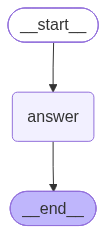

In [17]:
display(Image(graph.get_graph().draw_mermaid_png(max_retries=5, retry_delay=2.0)))

## Duas pacientes, duas unidades

Mesma pergunta, contextos diferentes. O prompt de sistema muda sozinho, sem tocar no código do agente.

In [18]:
response_centro = graph.invoke(
    {"messages": [HumanMessage("Com qual unidade da clínica estou falando?")]},
    context=ClinicContext(patient_id="123", unit="Centro"),
)
print(response_centro["messages"][-1].content)

runtime.context: ClinicContext(patient_id='123', unit='Centro')
Você está falando com a Clínica Alura, unidade Centro. Como posso ajudar?


In [19]:
response_zona_sul = graph.invoke(
    {"messages": [HumanMessage("Com qual unidade da clínica estou falando?")]},
    context=ClinicContext(patient_id="456", unit="Zona Sul"),
)
print(response_zona_sul["messages"][-1].content)

runtime.context: ClinicContext(patient_id='456', unit='Zona Sul')
Você está falando com a Clínica Alura, unidade Zona Sul. Como posso ajudar?


## config e context_schema juntos

Os dois parâmetros coexistem na mesma função de nó: `config` decide o modelo, `runtime.context` sabe de
qual paciente e unidade se trata. Cada um no seu escopo, sem um saber da existência do outro.

In [20]:
def answer_full(state: MessagesState, config: RunnableConfig, runtime: Runtime[ClinicContext]) -> dict:
    model = ChatOpenAI(
        model=config["configurable"]["model_name"],
        temperature=config["configurable"]["temperature"],
    )
    system_message = SystemMessage(
        f"Você é o assistente da Clínica Alura, unidade {runtime.context.unit}. "
        "Responda de forma cordial, curta e objetiva."
    )
    response = model.invoke([system_message] + state["messages"])
    return {"messages": [response]}

In [21]:
builder_full = StateGraph(MessagesState, context_schema=ClinicContext)
builder_full.add_node("answer_full", answer_full)
builder_full.add_edge(START, "answer_full")
builder_full.add_edge("answer_full", END)
graph_full = builder_full.compile()

In [ ]:
response = graph_full.invoke(
    input={"messages": [HumanMessage("Com qual unidade da clínica estou falando?")]},
    config={"configurable": {"model_name": "gpt-4o-mini", "temperature": 0}},
    context=ClinicContext(patient_id="123", unit="Centro"),
)
print(response["messages"][-1].content)

Você está falando com a Clínica Alura, unidade Centro. Como posso ajudar?


`config` e `context` chegaram juntos na mesma chamada, cada um resolvendo uma pergunta diferente: qual
modelo rodar, e de qual unidade falar. Nenhum dos dois precisa saber que o outro existe.

## O mesmo context_schema, agora no create_agent

`create_agent` aceita `context_schema` do mesmo jeito que o `StateGraph`: mesmo `ClinicContext`, mesmo
argumento `context` no `invoke`, o mesmo `Runtime` por baixo dos dois. Aceitar não é o mesmo que usar: o
que o agente faz com esse contexto depende de quem lê `runtime.context` depois, não do `create_agent`
sozinho.

In [23]:
agent = create_agent(
    model=model,
    tools=[],
    system_prompt="Você é o assistente da Clínica Alura. Responda de forma cordial, curta e objetiva.",
    context_schema=ClinicContext,
)

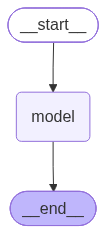

In [24]:
display(Image(agent.get_graph().draw_mermaid_png(max_retries=5, retry_delay=2.0)))

In [25]:
response = agent.invoke(
    {"messages": [HumanMessage("Com qual unidade da clínica estou falando?")]},
    context=ClinicContext(patient_id="123", unit="Centro"),
)
print(response["messages"][-1].content)

Você está falando com a Clínica Alura. Como posso ajudar você hoje?


A mesma pergunta que antes trazia "unidade Centro" agora sai sem menção nenhuma à unidade: o agente aceitou
o `context`, mas `system_prompt` aqui é uma string fixa, que não lê `runtime.context` sozinha. Sem tools,
não tem como usar o dado que chegou.

## Takeaway

`config["configurable"]` e `context_schema`/`Runtime` resolvem problemas diferentes, e coexistem na mesma
função de nó. `config` carrega o que a aplicação decide sobre a execução, como qual modelo ou qual
temperatura usar. `context_schema` carrega o dado de domínio que a aplicação modela, como `patient_id` e
`unit`, com tipo declarado. O mesmo padrão vale tanto para um `StateGraph` quanto para um `create_agent`. O
próximo passo é ler e escrever esse mesmo contexto de dentro de uma tool.